In [11]:
import pandas as pd
import pysam
import os
import json

# assemblies

In [12]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [13]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")

## Read in MSA

In [14]:
from __future__ import annotations

import os
import re
import json
from pathlib import Path
from typing import Union, List, Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) MSA FASTA -> DataFrame
# ============================================================
def msa_fasta_to_df(
    fasta_path: Union[str, Path],
    *,
    long: bool = False,
    keep_gaps: bool = True,
    fill_value: str = "-",
) -> pd.DataFrame:
    fasta_path = Path(fasta_path)
    if not fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {fasta_path}")

    seqs: Dict[str, str] = {}
    cur_id = None
    cur_chunks: List[str] = []

    def _commit():
        nonlocal cur_id, cur_chunks
        if cur_id is None:
            return
        seq = "".join(cur_chunks).strip()
        if not seq:
            raise ValueError(f"Empty sequence for record '{cur_id}' in {fasta_path}")
        if cur_id in seqs:
            raise ValueError(f"Duplicate FASTA header/id '{cur_id}' in {fasta_path}")
        seqs[cur_id] = seq
        cur_id, cur_chunks = None, []

    with fasta_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                _commit()
                cur_id = line[1:].split()[0]
                cur_chunks = []
            else:
                if cur_id is None:
                    raise ValueError("FASTA parse error: sequence line before any header ('>').")
                cur_chunks.append(line)
    _commit()

    if not seqs:
        raise ValueError(f"No sequences found in {fasta_path}")

    max_len = max(len(s) for s in seqs.values())
    ids = list(seqs.keys())
    mat = []
    for i in ids:
        s = seqs[i]
        if len(s) < max_len:
            s = s + (fill_value * (max_len - len(s)))
        elif len(s) > max_len:
            s = s[:max_len]
        mat.append(list(s))

    wide = pd.DataFrame(mat, index=ids, columns=pd.RangeIndex(1, max_len + 1, name="pos"))
    wide.index.name = "id"

    if not keep_gaps:
        wide = wide.replace("-", pd.NA)

    if not long:
        return wide

    long_df = (
        wide.reset_index()
            .melt(id_vars="id", var_name="pos", value_name="base")
            .sort_values(["id", "pos"], kind="stable")
            .reset_index(drop=True)
    )
    if not keep_gaps:
        long_df.loc[long_df["base"] == "-", "base"] = pd.NA
    return long_df


REGION_RE = re.compile(
    r"^(?P<contig>[^:]+):(?P<start>\d+)-(?P<end>\d+)_(?P<role>DELETED|FULL_5prime|FULL_3prime)$",
    re.IGNORECASE
)

def parse_row_id(row_id: str) -> Tuple[str, int, int, str]:
    m = REGION_RE.match(row_id)
    if not m:
        raise ValueError(f"Header does not match expected pattern contig:start-end_ROLE: {row_id}")
    contig = m.group("contig")
    start = int(m.group("start"))
    end   = int(m.group("end"))
    role  = m.group("role")
    role_u = role.upper()
    if role_u == "DELETED":
        role = "DELETED"
    elif role_u == "FULL_5PRIME":
        role = "FULL_5prime"
    elif role_u == "FULL_3PRIME":
        role = "FULL_3prime"
    return contig, start, end, role


def build_coordinate_dict(df_wide: pd.DataFrame) -> Dict[str, Dict[int, int]]:
    """
    Map alignment column -> genomic coordinate for each row.
    Walk from start toward end by +1 or -1 depending on start/end.
    Skip gaps: '-' doesn't advance coordinate.
    """
    coordinateDict: Dict[str, Dict[int, int]] = {r: {} for r in df_wide.index}

    for r in df_wide.index:
        contig, start_bp, end_bp, role = parse_row_id(r)
        step = 1 if end_bp >= start_bp else -1
        coord = start_bp

        for c in df_wide.columns:
            base = df_wide.at[r, c]
            if base == "-":
                continue
            coordinateDict[r][int(c)] = coord
            coord += step

    return coordinateDict


def find_deletion_vs_full_triplets(row_names: List[str]) -> List[Tuple[str, str, str, str]]:
    deleted_rows: List[str] = []
    full5_by_contig: Dict[str, str] = {}
    full3_by_contig: Dict[str, str] = {}

    for r in row_names:
        contig, start, end, role = parse_row_id(r)
        if role == "DELETED":
            deleted_rows.append(r)
        elif role == "FULL_5prime":
            full5_by_contig[contig] = r
        elif role == "FULL_3prime":
            full3_by_contig[contig] = r

    full_contigs = sorted(set(full5_by_contig) & set(full3_by_contig))

    triplets: List[Tuple[str, str, str, str]] = []
    for drow in deleted_rows:
        dcontig, *_ = parse_row_id(drow)
        for fcontig in full_contigs:
            group_label = f"{dcontig} (DELETED) vs {fcontig} (FULL)"
            triplets.append((group_label, drow, full5_by_contig[fcontig], full3_by_contig[fcontig]))
    return triplets


VALID_BASES = set("ACGT") 

def is_valid_base(x: str) -> bool:
    return isinstance(x, str) and (x.upper() in VALID_BASES)


def build_hits_deleted_two_panels(
    df_wide: pd.DataFrame,
    coordinateDict: Dict[str, Dict[int, int]],
    *,
    debug: bool = True,
    include_details: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    TWO stacked panels on DELETED coordinates:
      - Panel 1: DELETED vs FULL_5prime
      - Panel 2: DELETED vs FULL_3prime

    Column inclusion rules (STRICT):
      1) Column must have NO '-' in ANY row of the MSA (exclude all gappy columns).
      2) Column must be a SNP among A/C/G/T alleles across the MSA (>=2 alleles).
         (Other characters are ignored; if present, column likely fails comparisons anyway.)

    Additional filter:
      - DROP sites where FULL_5prime and FULL_3prime agree (same A/C/G/T) AND DELETED differs.

    Returns:
      hits_df columns: [Group, Side, Coordinate, Hit, MatchType]
      snp_dict for inspection
    """
    triplets = find_deletion_vs_full_triplets(list(df_wide.index))

    if debug:
        print(f"[DEBUG] rows in MSA: {df_wide.shape[0]}")
        print(f"[DEBUG] triplets found: {len(triplets)}")
        if len(triplets) == 0:
            print("[DEBUG] Row IDs:")
            for r in df_wide.index:
                print("  ", r)

    if not triplets:
        empty_df = pd.DataFrame(columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
        return empty_df, {}

    no_gap_cols = [int(col) for col in df_wide.columns if (df_wide[col] != "-").all()]
    if debug:
        print(f"[DEBUG] columns with NO gaps across all rows: {len(no_gap_cols)} / {df_wide.shape[1]}")

    snp_cols: List[int] = []
    for col in no_gap_cols:
        vals = df_wide[col].dropna().astype(str).str.upper()
        vals = vals[vals.map(lambda b: b in VALID_BASES)]
        if len(vals.unique()) >= 2:
            snp_cols.append(int(col))

    if debug:
        print(f"[DEBUG] SNP columns (no-gap; bases only): {len(snp_cols)}")

    if not snp_cols:
        empty_df = pd.DataFrame(columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
        return empty_df, {}

    out_rows: List[List[Any]] = []
    snp_dict: Dict[str, Any] = {}

    for group_label, drow, f5row, f3row in triplets:
        snp_dict.setdefault(group_label, {})
        for side in ["FULL_5prime", "FULL_3prime"]:
            snp_dict[group_label].setdefault(side, {
                "agree_coords": [],
                "disagree_coords": [],
                "agree_details": [] if include_details else None,
                "disagree_details": [] if include_details else None,
            })

        comparable_5 = agree_5 = disagree_5 = 0
        comparable_3 = agree_3 = disagree_3 = 0
        skipped_full_agree_deleted_diff = 0

        for col in snp_cols:
            b_del = str(df_wide.at[drow, col]).upper()
            b5    = str(df_wide.at[f5row, col]).upper()
            b3    = str(df_wide.at[f3row, col]).upper()

            del_ok = is_valid_base(b_del)
            b5_ok  = is_valid_base(b5)
            b3_ok  = is_valid_base(b3)

            if del_ok and b5_ok and b3_ok and (b5 == b3) and (b_del != b5):
                skipped_full_agree_deleted_diff += 1
                continue

            coord = coordinateDict.get(drow, {}).get(int(col))
            if coord is None:
                continue

            if del_ok and b5_ok:
                comparable_5 += 1
                mt = "Agree" if b_del == b5 else "Disagree"
                out_rows.append([group_label, "FULL_5prime", int(coord), 1, mt])

                if mt == "Agree":
                    agree_5 += 1
                    snp_dict[group_label]["FULL_5prime"]["agree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_5prime"]["agree_details"].append({
                            "coord": int(coord),
                            "col": int(col),
                            "deleted_base": b_del,
                            "full_base": b5,
                            "deleted_row": drow,
                            "full_row": f5row,
                        })
                else:
                    disagree_5 += 1
                    snp_dict[group_label]["FULL_5prime"]["disagree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_5prime"]["disagree_details"].append({
                            "coord": int(coord),
                            "col": int(col),
                            "deleted_base": b_del,
                            "full_base": b5,
                            "deleted_row": drow,
                            "full_row": f5row,
                        })

            if del_ok and b3_ok:
                comparable_3 += 1
                mt = "Agree" if b_del == b3 else "Disagree"
                out_rows.append([group_label, "FULL_3prime", int(coord), 1, mt])

                if mt == "Agree":
                    agree_3 += 1
                    snp_dict[group_label]["FULL_3prime"]["agree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_3prime"]["agree_details"].append({
                            "coord": int(coord),
                            "col": int(col),
                            "deleted_base": b_del,
                            "full_base": b3,
                            "deleted_row": drow,
                            "full_row": f3row,
                        })
                else:
                    disagree_3 += 1
                    snp_dict[group_label]["FULL_3prime"]["disagree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_3prime"]["disagree_details"].append({
                            "coord": int(coord),
                            "col": int(col),
                            "deleted_base": b_del,
                            "full_base": b3,
                            "deleted_row": drow,
                            "full_row": f3row,
                        })

        for side in ["FULL_5prime", "FULL_3prime"]:
            snp_dict[group_label][side]["agree_coords"] = sorted(set(snp_dict[group_label][side]["agree_coords"]))
            snp_dict[group_label][side]["disagree_coords"] = sorted(set(snp_dict[group_label][side]["disagree_coords"]))
            if include_details:
                snp_dict[group_label][side]["agree_details"].sort(key=lambda x: (x["coord"], x["col"]))
                snp_dict[group_label][side]["disagree_details"].sort(key=lambda x: (x["coord"], x["col"]))

        if debug:
            print(
                f"[DEBUG] {group_label}: skipped(full5==full3 & del!=full)={skipped_full_agree_deleted_diff} | "
                f"FULL_5prime comparable={comparable_5}, agree={agree_5}, disagree={disagree_5} | "
                f"FULL_3prime comparable={comparable_3}, agree={agree_3}, disagree={disagree_3}"
            )

    hits_df = pd.DataFrame(out_rows, columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
    return hits_df, snp_dict


def plot_deleted_two_panels(
    hits_df: pd.DataFrame,
    *,
    outFile: Optional[str] = None,
    point_size: float = 10,
    alpha: float = 0.85,
):
    if hits_df.empty:
        print("No SNP hits to plot.")
        return

    agg = (
        hits_df.groupby(["Group", "Side", "Coordinate", "MatchType"], as_index=False)["Hit"]
        .sum()
    )

    side_order = ["FULL_5prime", "FULL_3prime"]

    for group in sorted(agg["Group"].unique()):
        subg = agg[agg["Group"] == group].copy()

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), constrained_layout=True, sharex=True)

        xmin = int(subg["Coordinate"].min())
        xmax = int(subg["Coordinate"].max())
        pad = max(50, int((xmax - xmin) * 0.02))
        xlim = (xmin - pad, xmax + pad)

        for ax, side in zip(axes, side_order):
            sub = subg[subg["Side"] == side]
            if sub.empty:
                ax.set_title(f"{group} | {side} (no data)")
                ax.set_axis_off()
                continue

            for mt, color in [("Agree", "black"), ("Disagree", "red")]:
                ssub = sub[sub["MatchType"] == mt]
                if ssub.empty:
                    continue
                ax.scatter(
                    ssub["Coordinate"].astype(int).values,
                    ssub["Hit"].values,
                    s=point_size,
                    alpha=alpha,
                    c=color,
                    label=mt
                )

            ax.set_xlim(*xlim)
            ax.set_ylabel("Count")
            ax.set_title(f"{group} | {side} (DELETED coords)")
            ax.legend(frameon=False, loc="upper right")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        axes[-1].set_xlabel("Coordinate (DELETED)")

        if outFile:
            safe = re.sub(r"[^A-Za-z0-9]+", "_", group)
            if outFile.lower().endswith(".pdf"):
                of = outFile.replace(".pdf", f"__{safe}.pdf")
            else:
                of = outFile + f"__{safe}.pdf"
            plt.savefig(of, dpi=300)

        plt.show()


=== HG04228_HG04115_deletion_breakpoint_v2.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 129309 / 139868
[DEBUG] SNP columns (no-gap; bases only): 2441
[DEBUG] HG04228_chrY (DELETED) vs HG04115_chrY (FULL): skipped(full5==full3 & del!=full)=4 | FULL_5prime comparable=2437, agree=2422, disagree=15 | FULL_3prime comparable=2437, agree=15, disagree=2422


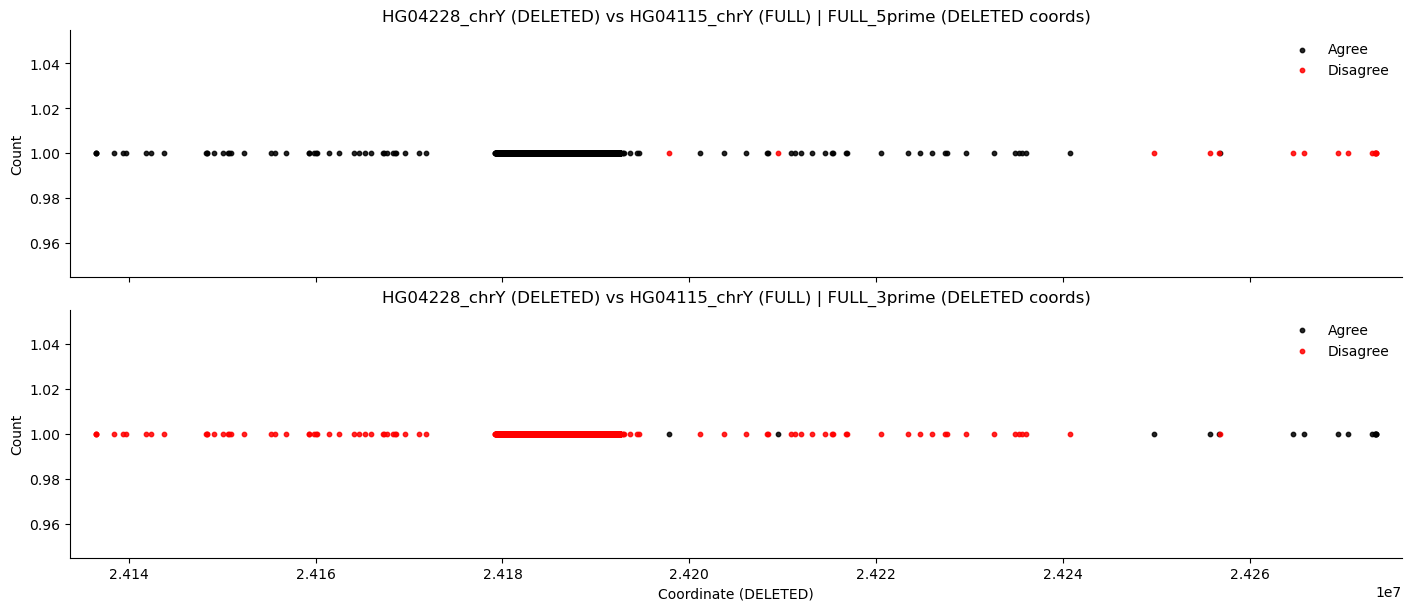

In [16]:
directory = "/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/"
out_dir   = "/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/alignments/"
os.makedirs(out_dir, exist_ok=True)

for fastaFile in os.listdir(directory):
    if not fastaFile.endswith(".fasta"):
        continue

    print(f"\n=== {fastaFile} ===")
    outFilePath = os.path.join(out_dir, f"DELETION_{fastaFile.split('.fasta')[0]}.pdf")

    df_wide = msa_fasta_to_df(os.path.join(directory, fastaFile))
    coordinateDict = build_coordinate_dict(df_wide)

    hits_df, snp_dict = build_hits_deleted_two_panels(
        df_wide,
        coordinateDict,
        debug=True,
        include_details=True
    )

    json_out = outFilePath.replace(".pdf", ".no_gap_cols.deleted_two_panels.snp_dict.json")
    with open(json_out, "w") as f:
        json.dump(snp_dict, f, indent=2)

    plot_deleted_two_panels(hits_df, outFile=outFilePath)
